<a href="https://colab.research.google.com/github/KEERTHANASRI-A-M-0609/keerthanasri-codeboosters-2026/blob/main/Day%204/Mini_Project_Day_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

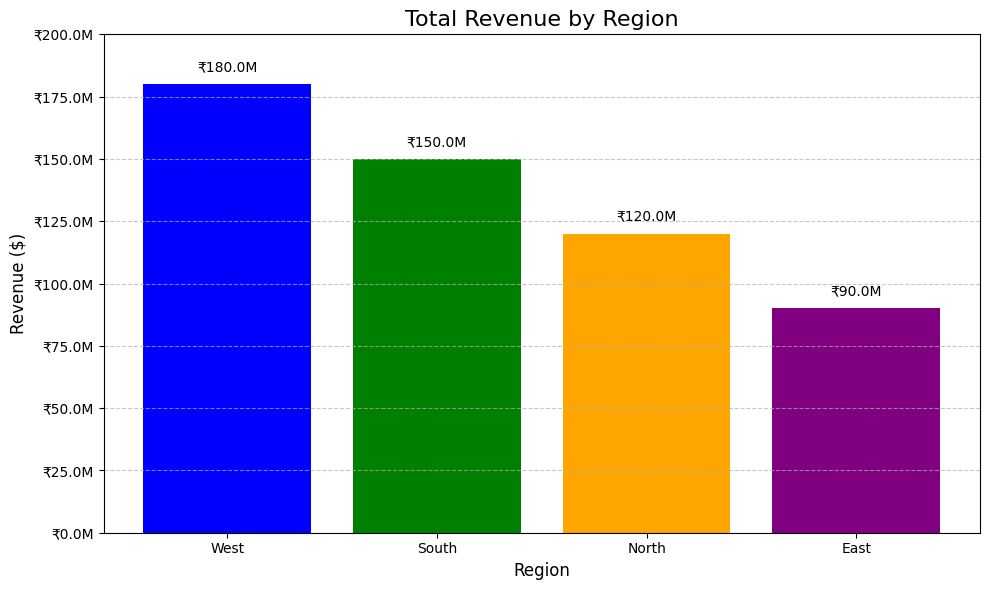

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Sample data with updated revenue values as per user request
data = {
    'Region': ['West', 'South', 'North', 'East'],
    'Revenue': [180000000, 150000000, 120000000, 90000000] # Updated revenue values
}
df = pd.DataFrame(data)

# Define colors for each region
colors = ['blue', 'green', 'orange', 'purple']

# Create the bar graph
plt.figure(figsize=(10, 6))
barplot = plt.bar(df['Region'], df['Revenue'], color=colors)

# Add title and labels
plt.title('Total Revenue by Region', fontsize=16)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Revenue ($)', fontsize=12)

# Set y-axis ticks from 0M to 200M with 25M intervals and format with rupee symbol
max_y_value = 200000000
y_tick_interval = 25000000
plt.yticks(np.arange(0, max_y_value + y_tick_interval, y_tick_interval))
plt.gca().set_yticklabels([f'₹{x/1000000:.1f}M' for x in np.arange(0, max_y_value + y_tick_interval, y_tick_interval)])

# Add revenue values above each bar with a rupee symbol
for bar in barplot:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02 * max_y_value, f'₹{yval/1000000:.1f}M', ha='center', va='bottom', fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [2]:
# Install PySpark
!pip install pyspark

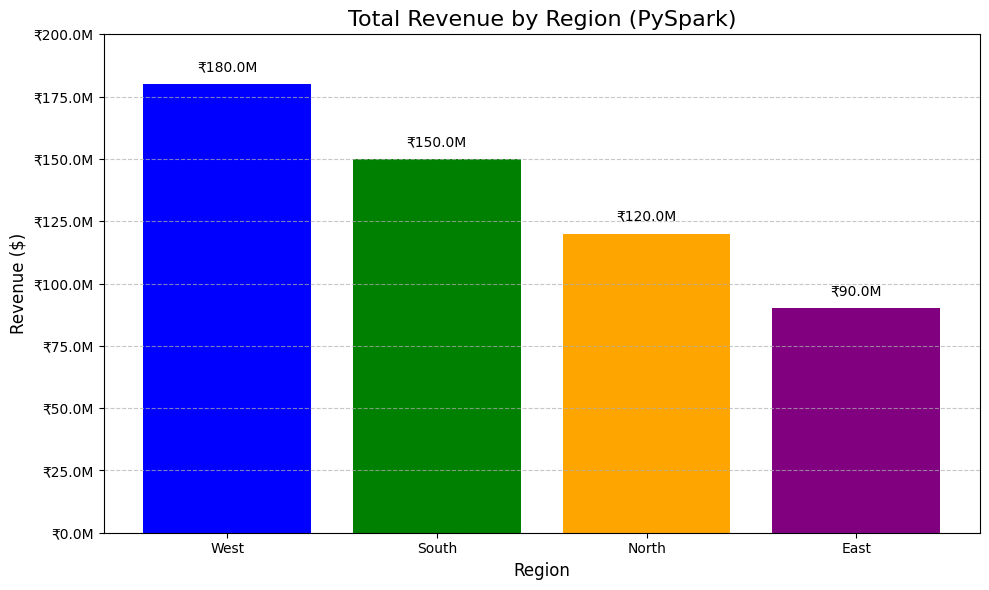

In [13]:
from pyspark.sql import SparkSession
from pyspark.sql.types import StructType, StructField, StringType, LongType
import matplotlib.pyplot as plt
import numpy as np

singlet_spark = SparkSession.builder.appName("RevenueAnalysis").getOrCreate()


data_spark = [
    ("West", 180000000),
    ("South", 150000000),
    ("North", 120000000),
    ("East", 90000000)
]

schema = StructType([
    StructField("Region", StringType(), True),
    StructField("Revenue", LongType(), True)
])


spark_df = singlet_spark.createDataFrame(data_spark, schema=schema)


# Convert PySpark DataFrame to Pandas DataFrame for plotting
df_pandas = spark_df.toPandas()

# Define colors for each region as per user request
colors = ['blue', 'green', 'orange', 'purple']

# Create the bar graph
plt.figure(figsize=(10, 6))
barplot = plt.bar(df_pandas['Region'], df_pandas['Revenue'], color=colors)

# Add title and labels
plt.title('Total Revenue by Region (PySpark)', fontsize=16)
plt.xlabel('Region', fontsize=12)
plt.ylabel('Revenue ($)', fontsize=12)

# Set y-axis ticks from 0M to 200M with 25M intervals and format with rupee symbol
max_y_value = 200000000
y_tick_interval = 25000000
plt.yticks(np.arange(0, max_y_value + y_tick_interval, y_tick_interval))
plt.gca().set_yticklabels([f'₹{x/1000000:.1f}M' for x in np.arange(0, max_y_value + y_tick_interval, y_tick_interval)])

# Add revenue values above each bar with a rupee symbol
for bar in barplot:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.02 * max_y_value, f'₹{yval/1000000:.1f}M', ha='center', va='bottom', fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

singlet_spark.stop()